# 09 · Every analysis on one large area: the canal ring of Amsterdam

**Question:** what do all eight area analyses show for one district, and how do I run
them together in the fewest calls?

The site is 1.5 km × 1.5 km of central Amsterdam: the Dam, the canal ring and the
Jordaan. We price all eight area analyses first, then send them in **one call**.
The SDK cuts the area into tiles and uploads the geometry of each tile one time.
Every analysis on the same tile grid uses that upload.

**Data.** This notebook uses public buildings, trees and ground surfaces
(`infrared-sdk[geodata]`). Source and heights vary by region. With your own model,
pass your layers instead (see `01_design_variants`).

In [1]:
import logging
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from infrared_sdk import (InfraredClient, PwcModelRequest, SolarModelRequest,
                          SolarRadiationModelRequest, SvfModelRequest, WindModelRequest)
from infrared_sdk.analyses.types import (
    AnalysesName, BaseAnalysisPayload, PwcCriteria, TcsModelBaseRequest, TcsModelRequest,
    TcsSubtype, UtciModelBaseRequest, UtciModelRequest)
from infrared_sdk.models import Location, TimePeriod

import ir_plot as irp

os.environ["INFRARED_QUIET"] = "1"  # no progress lines
logging.getLogger("infrared_sdk").setLevel(logging.ERROR)  # no start-up notes
client = InfraredClient()  # reads INFRARED_API_KEY

## 1. Area and public layers

In [2]:
lon, lat = 4.8900, 52.3705
polygon = irp.site(lon, lat, width_m=1500)
buildings = irp.cached_object("amsterdam-buildings", lambda: client.buildings.get_area(polygon))
trees = irp.cached_object("amsterdam-trees", lambda: client.vegetation.get_area(polygon))
ground = irp.cached_object("amsterdam-ground", lambda: client.ground_materials.get_area(polygon))
heights = [a["height"] for a in buildings.attributes.values() if a.get("height")]
print(f"{len(buildings.buildings):,} buildings (median {np.median(heights):.0f} m), "
      f"{trees.total_trees:,} trees, ground layers: "
      + ", ".join(f"{k} {len(v['features'])}" for k, v in ground.layers.items()))

9,697 buildings (median 14 m), 1,389 trees, ground layers: water 197, concrete 174, vegetation 231, soil 1, asphalt 849


## 2. Weather: one station, four time windows

The public weather catalog gives the typical year of the nearest station. Each analysis
gets the window that fits its question. The catalog returns the hours of one window.
For UTCI we find the hottest week of the year in the weather rows.

In [3]:
station = client.weather.get_weather_file_from_location(lat=lat, lon=lon)[0]
def hours_of(period: TimePeriod) -> list:
    return client.weather.filter_weather_data(identifier=station["uuid"], time_period=period)

year = hours_of(TimePeriod(start_month=1, start_day=1, start_hour=0,
                           end_month=12, end_day=31, end_hour=23))

# The hottest week of the typical year: the 7 days with the warmest afternoons (13-16 h).
air = pd.Series([h.dryBulbTemperature for h in year],
                index=pd.date_range("2023-01-01", periods=len(year), freq="h"))  # a non-leap year
afternoons = air[air.index.hour.isin(range(13, 17))].resample("D").mean()
last = afternoons.rolling(7).mean().idxmax()
first = last - pd.Timedelta(days=6)

WINDOWS = {  # month, day, hour of the first and the last hour
    "summer": TimePeriod(start_month=6, start_day=1, start_hour=6, end_month=8, end_day=31, end_hour=20),
    "hottest week": TimePeriod(start_month=first.month, start_day=first.day, start_hour=13,
                               end_month=last.month, end_day=last.day, end_hour=16),
    "summer days": TimePeriod(start_month=6, start_day=1, start_hour=10, end_month=9, end_day=30, end_hour=18),
}
weather = {"year": year} | {name: hours_of(period) for name, period in WINDOWS.items()}

# The prevailing wind: the most frequent of 16 sectors, and its mean speed.
speed = np.array([h.windSpeed for h in year], dtype=float)
direction = np.array([h.windDirection for h in year], dtype=float)
sector = np.round(direction / 22.5).astype(int) % 16
prevailing = int(np.bincount(sector[speed > 0], minlength=16).argmax())
wind_dir = int(prevailing * 22.5)
wind_speed = float(speed[(sector == prevailing) & (speed > 0)].mean())
print(f"{station['fileName']}: " + ", ".join(f"{k} {len(v)} h" for k, v in weather.items()))
print(f"hottest week {first:%d %b} to {last:%d %b}, afternoon air {afternoons[first:last].mean():.1f} °C")
print(f"prevailing wind from {wind_dir}° at {wind_speed:.1f} m/s")

NLD_NH_Amsterdam-Schipol.AP.062400_TMYx.2009-2023: year 8760 h, summer 1380 h, hottest week 28 h, summer days 1098 h
hottest week 28 Jun to 04 Jul, afternoon air 25.2 °C
prevailing wind from 270° at 6.4 m/s


## 3. Eight requests

Sky view factor needs only geometry. The sun analyses need a location and a window.
The comfort analyses also need the weather rows of their window.

In [4]:
location = Location(latitude=lat, longitude=lon)
requests = {
    "sky view factor": SvfModelRequest(analysis_type=AnalysesName.sky_view_factors),
    "solar radiation": SolarRadiationModelRequest.from_weatherfile_payload(
        payload=BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation),
        location=location, time_period=WINDOWS["summer"], weather_data=weather["summer"]),
    "direct sun hours": SolarModelRequest(
        analysis_type=AnalysesName.direct_sun_hours, latitude=lat, longitude=lon,
        time_period=WINDOWS["summer"]),
    "daylight availability": SolarModelRequest(
        analysis_type=AnalysesName.daylight_availability, latitude=lat, longitude=lon,
        time_period=TimePeriod(start_month=1, start_day=1, start_hour=8,
                               end_month=12, end_day=31, end_hour=18)),
    "UTCI": UtciModelRequest.from_weatherfile_payload(
        payload=UtciModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_index),
        location=location, time_period=WINDOWS["hottest week"], weather_data=weather["hottest week"]),
    "TCS heat stress": TcsModelRequest.from_weatherfile_payload(
        payload=TcsModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_statistics,
                                    subtype=TcsSubtype.heat_stress),
        location=location, time_period=WINDOWS["summer days"],
        weather_data=weather["summer days"]),
    "wind speed": WindModelRequest(analysis_type=AnalysesName.wind_speed,
                                   wind_speed=wind_speed, wind_direction=wind_dir),
    "pedestrian wind comfort": PwcModelRequest(
        analysis_type=AnalysesName.pedestrian_wind_comfort, criteria=PwcCriteria.lawson_lddc,
        wind_speed=speed.tolist(), wind_direction=direction.tolist()),
}

## 4. Preview all eight before you pay

`preview_area` is free and runs on your machine. One call prices one analysis.

In [5]:
rows = []
for name, request in requests.items():
    p = client.preview_area(polygon, payload=request)
    rows.append({"analysis": name, "tiles": p.tile_count, "jobs": p.would_bill_jobs,
                 "tokens": p.estimated_cost_tokens})
costs = pd.DataFrame(rows).set_index("analysis")
costs.loc["total"] = costs.sum()
costs

,tiles,jobs,tokens
analysis,,,
sky view factor,9,9,90
solar radiation,9,9,90
direct sun hours,9,9,90
daylight availability,9,9,90
UTCI,9,9,90
TCS heat stress,9,9,90
wind speed,36,36,360
pedestrian wind comfort,36,36,360
total,126,126,1260


**What you see:** the six sun, light and comfort analyses share one grid of 512 m
tiles: 9 tiles for this area. The two wind analyses use overlapping tiles with a
step of 256 m, so they need four times more jobs. Wind is most of the cost.

## 5. One call for all eight

`run_area` takes a list of requests and returns one schedule for each. We check all
schedules until they are complete (`known=` keeps the job states between checks, so a
check asks only for the jobs that are still open), then merge each one into a map.
Wind speed is merged with the **directional blend**: overlapping wind tiles are joined
along the wind direction.

In [6]:
def run_all() -> dict:
    start = time.perf_counter()
    schedules = dict(zip(requests, client.run_area(
        list(requests.values()), polygon, buildings=buildings,
        vegetation=trees.features, ground_materials=ground.layers)))
    known = {name: {} for name in schedules}  # job states, reused between checks
    while not all(client.check_area_state(s, known=known[n]).is_complete
                  for n, s in schedules.items()):
        time.sleep(2)
    grids = {}
    for name, schedule in schedules.items():
        if name == "wind speed":
            result = client.merge_area_jobs(schedule, strategy="directional_blend",
                                            wind_direction_deg=wind_dir)
        else:
            result = client.merge_area_jobs(schedule)
        grids[name] = irp.Grid.of(result)
    return {"grids": grids, "seconds": time.perf_counter() - start}

run = irp.cached_object("amsterdam-all-analyses", run_all)
grids = run["grids"]
print(f"{len(grids)} maps, {int(costs.loc['total', 'jobs'])} jobs, "
      f"{int(costs.loc['total', 'tokens'])} tokens, wall time {run['seconds'] / 60:.1f} min")

8 maps, 126 jobs, 1260 tokens, wall time 0.4 min


**What you see:** the jobs of all eight analyses run at the same time, so the whole
run takes less than a minute. The maps are kept on disk (`irp.cached_object`):
a second run of the notebook reads them and costs nothing.

## 6. Eight maps of one district

Each analysis has its own colour map and unit. North is up.

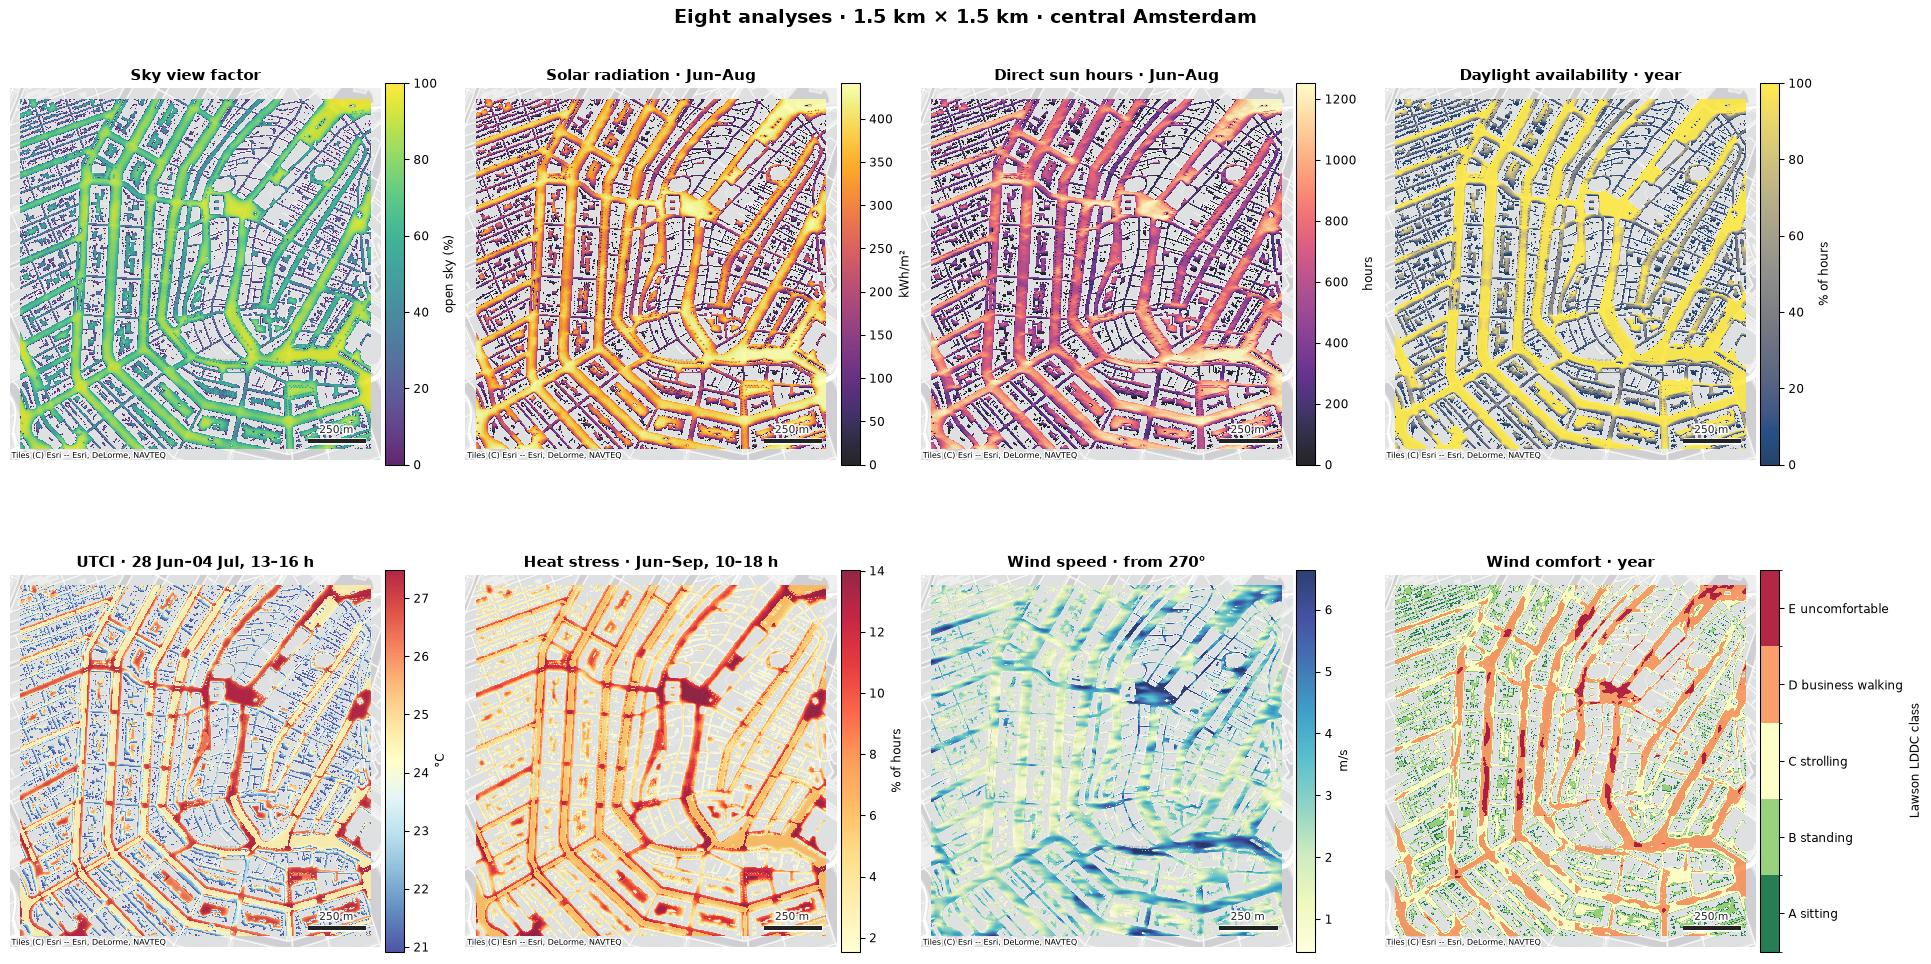

In [7]:
LDDC = {"A": "sitting", "B": "standing", "C": "strolling", "D": "business walking",
        "E": "uncomfortable"}
grids["pedestrian wind comfort"].legend = [
    f"{c} {LDDC.get(c, '')}" for c in grids["pedestrian wind comfort"].legend]

PANELS = {  # title, legend label, fixed colour range (None = 1st to 99th percentile)
    "sky view factor": ("Sky view factor", "open sky (%)", (0, 100)),
    "solar radiation": ("Solar radiation · Jun–Aug", "kWh/m²", None),
    "direct sun hours": ("Direct sun hours · Jun–Aug", "hours", None),
    "daylight availability": ("Daylight availability · year", "% of hours", (0, 100)),
    "UTCI": (f"UTCI · {first:%d %b}–{last:%d %b}, 13–16 h", "°C", None),
    "TCS heat stress": ("Heat stress · Jun–Sep, 10–18 h", "% of hours", None),
    "wind speed": (f"Wind speed · from {wind_dir}°", "m/s", None),
    "pedestrian wind comfort": ("Wind comfort · year", "Lawson LDDC class", None),
}
fig, axes = plt.subplots(2, 4, figsize=(20, 10.4), layout="constrained")
for ax, (name, (title, label, limits)) in zip(axes.flat, PANELS.items()):
    grid = grids[name]
    if limits is None and not grid.legend:
        limits = tuple(np.nanpercentile(grid.values, [1, 99]))
    vmin, vmax = limits or (None, None)
    image = irp.map_grid(grid, ax, title=title, colorbar=False, vmin=vmin, vmax=vmax,
                         scale_m=250)
    bar = fig.colorbar(image, ax=ax, shrink=0.8, pad=0.01, label=label)
    if grid.legend:  # classes: one tick for each class, like the other colour bars
        ax.get_legend().remove()
        bar.set_ticks(range(len(grid.legend)), labels=grid.legend)
fig.suptitle("Eight analyses · 1.5 km × 1.5 km · central Amsterdam", fontsize=14)
plt.show()

**What you see:** one district, eight questions. The canals and the wide streets have
the most open sky, the most sun and the most daylight. The narrow streets and the
courtyards get little direct sun. In the afternoons of the hottest week, the canals,
the Dam square and the wide streets are the hottest places: UTCI is above 26 °C on
about a fifth of the open ground. The shaded narrow streets stay near 21 °C. The
heat-stress map shows the same pattern for the whole summer, with up to 14 % of the
daytime hours on open, sunny ground. The west wind (270°) is fastest on the open
water and on the Dam. In a typical year, about a third of the open ground is class C
(strolling) and a third is class D (business walking). 4 % is class E (uncomfortable),
mostly on the canals and on the Dam. Courtyards are calm (classes A and B).

## 7. Wind speed in detail

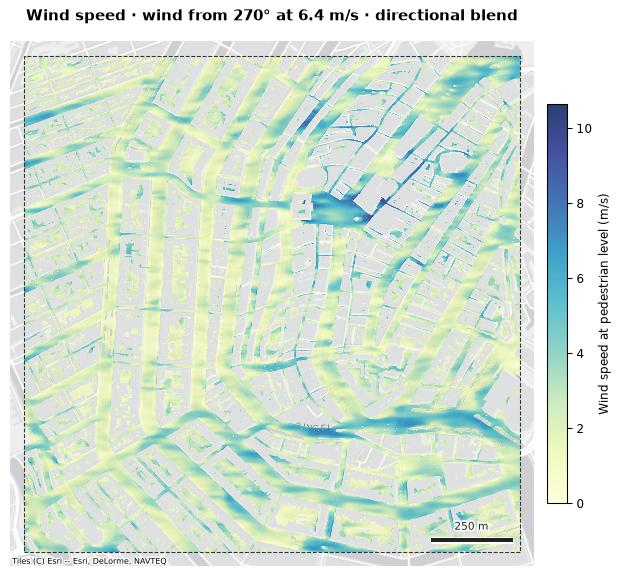

In [8]:
irp.map_grid(grids["wind speed"], polygon=polygon, vmin=0, scale_m=250,
             label="Wind speed at pedestrian level (m/s)",
             title=f"Wind speed · wind from {wind_dir}° at {wind_speed:.1f} m/s · directional blend")
plt.show()

**What you see:** fast bands run along the canals and the streets that point west to
east, and the lee of each block is calm. The wind tiles overlap; the directional blend
joins them along the wind. No seams show at the tile borders.

## Next

- `08_scale_and_cost`: how the upload reuse works, and a 2 km area.
- `03_wind_comfort`: the two wind analyses in detail.
- Guide, the analyses: <https://infrared.city/docs/sdk/1.0/#the-ten-analyses>
- Guide, tiling: <https://infrared.city/docs/sdk/1.0/#tiling>